# Intermediate Regression with statsmodels in Python
**WU Vienna · ExInt II · Jonas Pamminger**

This notebook covers all topics from the DataCamp course:
1. Logistic Regression
2. Model Evaluation (confusion matrix, ROC curve)
3. Poisson Regression (count data)
4. Negative Binomial Regression
5. Ordinal & Multinomial Logistic Regression

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded ✓')

Libraries loaded ✓


---
## Chapter 1 — Logistic Regression

Logistic regression predicts a **binary outcome** (0/1, yes/no).  
Instead of a straight line, it estimates the **probability** that Y=1.

$$P(Y=1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}}$$

Key idea: we model the **log-odds** (logit) as a linear function of X.

In [2]:
# --- Simulate dataset: predict whether a firm enters a new market (1=yes, 0=no)
np.random.seed(42)
n = 500

df = pd.DataFrame({
    'firm_size':     np.random.normal(50, 20, n).clip(5, 150),   # employees (hundreds)
    'experience':    np.random.randint(1, 30, n),                 # years international experience
    'distance':      np.random.uniform(100, 5000, n),             # psychic distance to target market
    'rd_intensity':  np.random.beta(2, 5, n),                     # R&D / sales ratio
})

# True data-generating process
log_odds = (-2
            + 0.03 * df['firm_size']
            + 0.08 * df['experience']
            - 0.0003 * df['distance']
            + 3.0  * df['rd_intensity'])

prob = 1 / (1 + np.exp(-log_odds))
df['market_entry'] = np.random.binomial(1, prob)

print(df.head())
print(f"\nEntry rate: {df['market_entry'].mean():.2%}")

   firm_size  experience     distance  rd_intensity  market_entry
0  59.934283          26  4130.660992      0.131926             1
1  47.234714           2  2695.342225      0.246151             1
2  62.953771          27  4093.766699      0.250128             1
3  80.460597          24  2540.644692      0.272997             1
4  45.316933          27   429.159460      0.227567             1

Entry rate: 64.00%


/var/folders/p_/h6dvpmm17sn15bkyll6m0tpc0000gn/T/ipykernel_89020/1712063106.py:20: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['market_entry'] = np.random.binomial(1, prob)


In [3]:
# --- Fit logistic regression with statsmodels formula API
model_logit = smf.logit(
    'market_entry ~ firm_size + experience + distance + rd_intensity',
    data=df
).fit()

print(model_logit.summary())

Optimization terminated successfully.
         Current function value: 0.538911
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           market_entry   No. Observations:                  500
Model:                          Logit   Df Residuals:                      495
Method:                           MLE   Df Model:                            4
Date:                Tue, 26 May 2026   Pseudo R-squ.:                  0.1752
Time:                        12:32:29   Log-Likelihood:                -269.46
converged:                       True   LL-Null:                       -326.71
Covariance Type:            nonrobust   LLR p-value:                 7.952e-24
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.8548      0.450     -4.123      0.000      -2.736      -0.973
firm_size        0.0394

In [4]:
# --- Interpreting coefficients as ODDS RATIOS
# Exponentiate coefficients: OR > 1 means higher odds of entry
odds_ratios = np.exp(model_logit.params)
conf_int_or = np.exp(model_logit.conf_int())
conf_int_or.columns = ['OR 2.5%', 'OR 97.5%']

result = pd.concat([odds_ratios.rename('Odds Ratio'), conf_int_or], axis=1)
print(result.round(3))

              Odds Ratio  OR 2.5%  OR 97.5%
Intercept          0.156    0.065     0.378
firm_size          1.040    1.028     1.053
experience         1.066    1.039     1.093
distance           1.000    0.999     1.000
rd_intensity      16.755    4.211    66.665


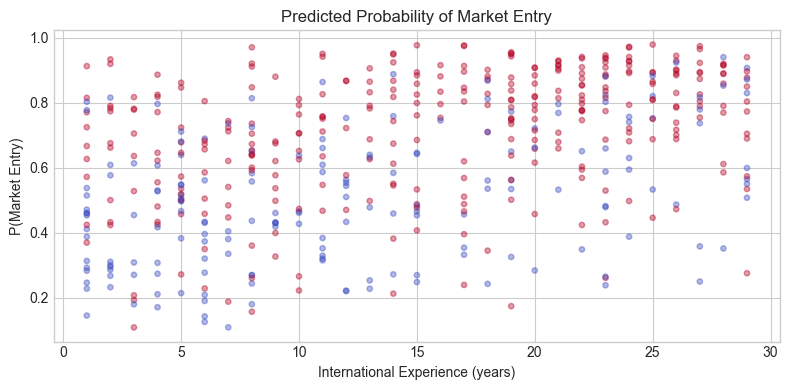

In [5]:
# --- Predicted probabilities
df['pred_prob'] = model_logit.predict(df)

# Visualise predicted probability vs. experience
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df['experience'], df['pred_prob'],
           c=df['market_entry'], cmap='coolwarm', alpha=0.4, s=15)
ax.set_xlabel('International Experience (years)')
ax.set_ylabel('P(Market Entry)')
ax.set_title('Predicted Probability of Market Entry')
plt.tight_layout()
plt.savefig('../output/figures/logit_predictions.png', dpi=150)
plt.show()

---
## Chapter 2 — Model Evaluation

### 2.1 Confusion Matrix
Convert probabilities to class predictions using a threshold (default: 0.5).

|  | Predicted 0 | Predicted 1 |
|--|--|--|
| **Actual 0** | TN | FP |
| **Actual 1** | FN | TP |

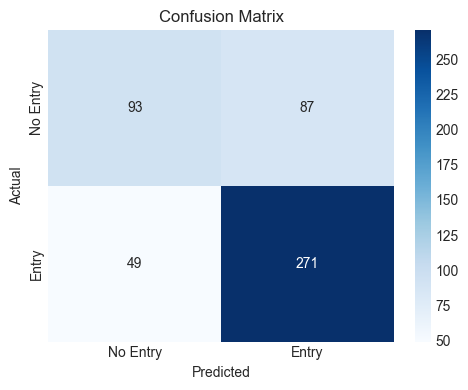

Accuracy:  72.80%
Precision: 75.70%
Recall:    84.69%


In [6]:
# Confusion matrix at threshold 0.5
df['pred_class'] = (df['pred_prob'] >= 0.5).astype(int)

cm = confusion_matrix(df['market_entry'], df['pred_class'])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Entry', 'Entry'],
            yticklabels=['No Entry', 'Entry'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('../output/figures/confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Accuracy:  {(tp+tn)/(tp+tn+fp+fn):.2%}')
print(f'Precision: {tp/(tp+fp):.2%}')
print(f'Recall:    {tp/(tp+fn):.2%}')

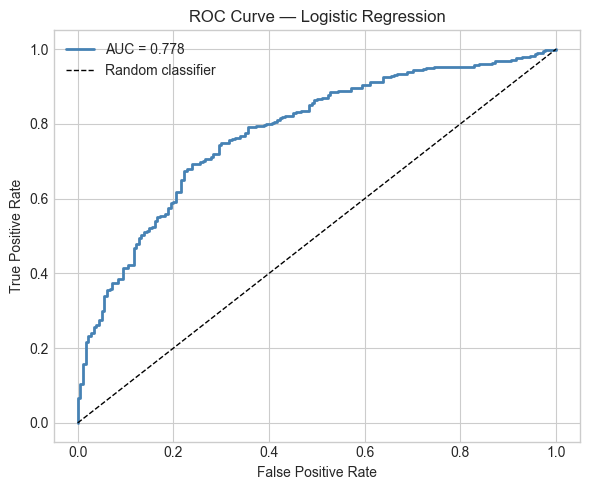

In [7]:
# --- ROC Curve & AUC
fpr, tpr, thresholds = roc_curve(df['market_entry'], df['pred_prob'])
auc = roc_auc_score(df['market_entry'], df['pred_prob'])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
ax.plot([0,1], [0,1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression')
ax.legend()
plt.tight_layout()
plt.savefig('../output/figures/roc_curve.png', dpi=150)
plt.show()

In [8]:
# --- Pseudo R-squared (McFadden)
# McFadden R² = 1 - (log-likelihood model / log-likelihood null)
print(f"McFadden R²: {model_logit.prsquared:.4f}")
print(f"Log-likelihood: {model_logit.llf:.2f}")
print(f"AIC: {model_logit.aic:.2f}")
print(f"BIC: {model_logit.bic:.2f}")

McFadden R²: 0.1752
Log-likelihood: -269.46
AIC: 548.91
BIC: 569.98


---
## Chapter 3 — Poisson Regression (Count Data)

Use Poisson regression when the outcome is a **count** (0, 1, 2, 3, ...).
Examples: number of foreign subsidiaries, number of alliances, patents.

$$\log(E[Y]) = \beta_0 + \beta_1 x_1 + \ldots$$

Assumption: **mean = variance** (equidispersion).

Subsidiaries distribution:
count    500.00
mean       4.99
std        3.46
min        0.00
25%        2.00
50%        4.00
75%        7.00
max       20.00
Name: subsidiaries, dtype: float64
Mean: 4.99 | Var: 12.00


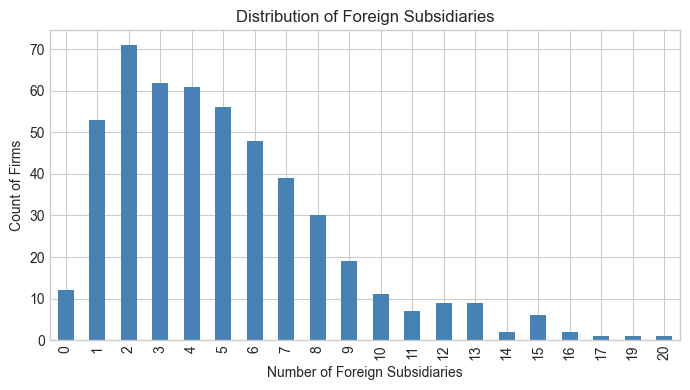

In [9]:
# --- Simulate count outcome: number of foreign subsidiaries
np.random.seed(99)

df['subsidiaries'] = np.random.poisson(
    lam=np.exp(0.5 + 0.015 * df['firm_size']
               + 0.04  * df['experience']
               - 0.00015 * df['distance'])
)

print("Subsidiaries distribution:")
print(df['subsidiaries'].describe().round(2))
print(f"Mean: {df['subsidiaries'].mean():.2f} | Var: {df['subsidiaries'].var():.2f}")

fig, ax = plt.subplots(figsize=(7, 4))
df['subsidiaries'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Number of Foreign Subsidiaries')
ax.set_ylabel('Count of Firms')
ax.set_title('Distribution of Foreign Subsidiaries')
plt.tight_layout()
plt.savefig('../output/figures/subsidiaries_dist.png', dpi=150)
plt.show()

In [10]:
# --- Fit Poisson regression
model_poisson = smf.poisson(
    'subsidiaries ~ firm_size + experience + distance',
    data=df
).fit()

print(model_poisson.summary())

Optimization terminated successfully.
         Current function value: 2.106697
         Iterations 10
                          Poisson Regression Results                          
Dep. Variable:           subsidiaries   No. Observations:                  500
Model:                        Poisson   Df Residuals:                      496
Method:                           MLE   Df Model:                            3
Date:                Tue, 26 May 2026   Pseudo R-squ.:                  0.2379
Time:                        12:32:35   Log-Likelihood:                -1053.3
converged:                       True   LL-Null:                       -1382.2
Covariance Type:            nonrobust   LLR p-value:                3.143e-142
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4477      0.082      5.467      0.000       0.287       0.608
firm_size      0.0151      0

In [11]:
# --- Interpret Poisson coefficients as Incidence Rate Ratios (IRR)
# exp(coef): a 1-unit increase in X multiplies the expected count by exp(coef)
irr = np.exp(model_poisson.params)
ci  = np.exp(model_poisson.conf_int())
ci.columns = ['IRR 2.5%', 'IRR 97.5%']

print(pd.concat([irr.rename('IRR'), ci], axis=1).round(4))

               IRR  IRR 2.5%  IRR 97.5%
Intercept   1.5647    1.3327     1.8371
firm_size   1.0153    1.0133     1.0173
experience  1.0447    1.0397     1.0498
distance    0.9999    0.9998     0.9999


In [12]:
# --- Test for overdispersion (var >> mean → Poisson assumption violated)
mean_y = df['subsidiaries'].mean()
var_y  = df['subsidiaries'].var()
dispersion_ratio = var_y / mean_y

print(f"Mean:      {mean_y:.3f}")
print(f"Variance:  {var_y:.3f}")
print(f"Var/Mean:  {dispersion_ratio:.3f}  ({'OVERDISPERSED → use NegBin' if dispersion_ratio > 1.5 else 'OK for Poisson'})")

Mean:      4.990
Variance:  11.998
Var/Mean:  2.404  (OVERDISPERSED → use NegBin)


---
## Chapter 4 — Negative Binomial Regression

When count data is **overdispersed** (variance > mean), use Negative Binomial.
It adds a dispersion parameter α to account for extra variance.

- α ≈ 0 → reduces to Poisson  
- α > 0 → overdispersion present → NegBin is more appropriate

In [13]:
# --- Simulate overdispersed count data
np.random.seed(7)
mu = np.exp(0.5 + 0.015 * df['firm_size'] + 0.04 * df['experience'])
alpha = 0.8   # overdispersion parameter

# NegBin via gamma-Poisson mixture
gamma_noise = np.random.gamma(shape=1/alpha, scale=alpha*mu)
df['subsidiaries_od'] = np.random.poisson(gamma_noise)

print(f"Overdispersed — Mean: {df['subsidiaries_od'].mean():.2f} | Var: {df['subsidiaries_od'].var():.2f}")
print(f"Var/Mean ratio: {df['subsidiaries_od'].var()/df['subsidiaries_od'].mean():.2f}")

Overdispersed — Mean: 6.31 | Var: 49.06
Var/Mean ratio: 7.78


In [14]:
# --- Fit Negative Binomial regression
model_negbin = smf.negativebinomial(
    'subsidiaries_od ~ firm_size + experience + distance',
    data=df
).fit(disp=False)

print(model_negbin.summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:        subsidiaries_od   No. Observations:                  500
Model:               NegativeBinomial   Df Residuals:                      496
Method:                           MLE   Df Model:                            3
Date:                Tue, 26 May 2026   Pseudo R-squ.:                 0.02388
Time:                        12:32:35   Log-Likelihood:                -1423.8
converged:                       True   LL-Null:                       -1458.6
Covariance Type:            nonrobust   LLR p-value:                 5.071e-15
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6004      0.176      3.408      0.001       0.255       0.946
firm_size      0.0141      0.002      5.887      0.000       0.009       0.019
experience     0.0337      0.005      6.489      0.0

/Users/jonaspamminger/Desktop/Studium/sme-internationalization/.venv/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/Users/jonaspamminger/Desktop/Studium/sme-internationalization/.venv/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


In [15]:
# --- Compare Poisson vs NegBin via AIC
model_poisson_od = smf.poisson(
    'subsidiaries_od ~ firm_size + experience + distance', data=df
).fit(disp=False)

print(f"Poisson  AIC: {model_poisson_od.aic:.2f}")
print(f"NegBin   AIC: {model_negbin.aic:.2f}")
print(f"→ Lower AIC is better. NegBin wins when data is overdispersed.")

Poisson  AIC: 4319.07
NegBin   AIC: 2857.54
→ Lower AIC is better. NegBin wins when data is overdispersed.


---
## Chapter 5 — Multinomial & Ordinal Logistic Regression

### 5.1 Multinomial Logistic Regression
Outcome has **3+ unordered categories**.  
Example: entry mode (export / joint venture / wholly owned subsidiary)

In [16]:
# --- Simulate entry mode (0=export, 1=JV, 2=WOS)
np.random.seed(21)
logits = np.column_stack([
    np.zeros(n),                                                            # base: export
    -1 + 0.02*df['firm_size'] + 0.05*df['experience'],                     # JV
    -3 + 0.04*df['firm_size'] + 0.08*df['experience'] - 0.0003*df['distance']  # WOS
])
exp_logits  = np.exp(logits)
probs_multi = exp_logits / exp_logits.sum(axis=1, keepdims=True)
df['entry_mode'] = np.array([np.random.choice([0,1,2], p=p) for p in probs_multi])
df['entry_mode_label'] = df['entry_mode'].map({0:'Export', 1:'JV', 2:'WOS'})

print(df['entry_mode_label'].value_counts())

entry_mode_label
JV        279
Export    130
WOS        91
Name: count, dtype: int64


In [17]:
# --- Fit Multinomial Logistic Regression
model_mnl = smf.mnlogit(
    'entry_mode ~ firm_size + experience + distance',
    data=df
).fit()

print(model_mnl.summary())

Optimization terminated successfully.
         Current function value: 0.917680
         Iterations 6


                          MNLogit Regression Results                          
Dep. Variable:             entry_mode   No. Observations:                  500
Model:                        MNLogit   Df Residuals:                      492
Method:                           MLE   Df Model:                            6
Date:                Tue, 26 May 2026   Pseudo R-squ.:                 0.06916
Time:                        12:32:36   Log-Likelihood:                -458.84
converged:                       True   LL-Null:                       -492.93
Covariance Type:            nonrobust   LLR p-value:                 9.665e-13
entry_mode=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.5826      0.392     -1.485      0.138      -1.352       0.186
firm_size        0.0167      0.006      2.870      0.004       0.005       0.028
experience       0.0401      0.013      3.05

### 5.2 Ordinal Logistic Regression
Outcome has **3+ ordered categories**.  
Example: internationalisation stage (1=domestic, 2=exporter, 3=MNE)

In [18]:
# --- Ordinal outcome: internationalisation stage
from statsmodels.miscmodels.ordinal_model import OrderedModel

latent = (0.03*df['firm_size']
         + 0.06*df['experience']
         - 0.0002*df['distance']
         + np.random.normal(0, 1, n))

df['intl_stage'] = pd.cut(latent,
                           bins=[-np.inf, -0.5, 1.0, np.inf],
                           labels=['Domestic', 'Exporter', 'MNE'])

print(df['intl_stage'].value_counts())

intl_stage
MNE         367
Exporter    118
Domestic     15
Name: count, dtype: int64


In [19]:
# --- Fit Ordered Logit (Proportional Odds Model)
model_ordinal = OrderedModel(
    df['intl_stage'],
    df[['firm_size', 'experience', 'distance']],
    distr='logit'
).fit(method='bfgs', disp=False)

print(model_ordinal.summary())

                             OrderedModel Results                             
Dep. Variable:             intl_stage   Log-Likelihood:                -275.83
Model:                   OrderedModel   AIC:                             561.7
Method:            Maximum Likelihood   BIC:                             582.7
Date:                Tue, 26 May 2026                                         
Time:                        12:32:36                                         
No. Observations:                 500                                         
Df Residuals:                     495                                         
Df Model:                           3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
firm_size             0.0469      0.007      7.046      0.000       0.034       0.060
experience            0.1042   

---
## Summary: Which Model to Use?

| Outcome type | Model | statsmodels function |
|---|---|---|
| Binary (0/1) | Logistic Regression | `smf.logit()` |
| Count (equidispersed) | Poisson | `smf.poisson()` |
| Count (overdispersed) | Negative Binomial | `smf.negativebinomial()` |
| Categorical (unordered) | Multinomial Logit | `smf.mnlogit()` |
| Categorical (ordered) | Ordered Logit | `OrderedModel()` |

**Rule of thumb for count data:**  
1. Check Var/Mean ratio → if > 1.5: use Negative Binomial  
2. Compare AIC: lower = better fit  
3. Always check residuals and goodness-of-fit

In [20]:
# --- Save all model results to output/tables
results = pd.DataFrame({
    'Model':    ['Logit', 'Poisson', 'NegBin', 'Multinomial', 'Ordinal'],
    'AIC':      [model_logit.aic, model_poisson_od.aic, model_negbin.aic,
                 model_mnl.aic, model_ordinal.aic],
    'Outcome':  ['Binary', 'Count', 'Count (OD)', 'Categorical', 'Ordered']
})
results.to_csv('../output/tables/model_comparison.csv', index=False)
print(results.round(2))
print('\nSaved to output/tables/model_comparison.csv ✓')

         Model      AIC      Outcome
0        Logit   548.91       Binary
1      Poisson  4319.07        Count
2       NegBin  2857.54   Count (OD)
3  Multinomial   933.68  Categorical
4      Ordinal   561.66      Ordered

Saved to output/tables/model_comparison.csv ✓
